Dữ liệu Train: 2022-01-13 00:00:00 đến 2024-12-31 23:00:00
Dữ liệu Test (để soi Bias): Năm 2025


19:36:22 - cmdstanpy - INFO - Chain [1] start processing
19:36:41 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\BUI QUANG HUNG\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


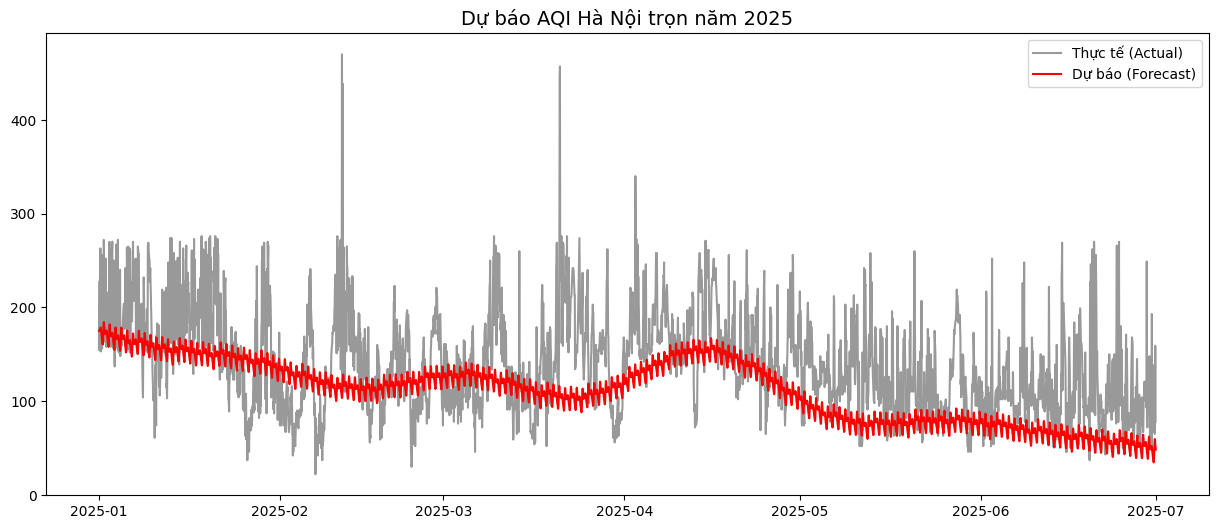

C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_25752\3836001304.py:47: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_season = eval_df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))
C:\Users\BUI QUANG HUNG\AppData\Local\Temp\ipykernel_25752\3836001304.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rmse_hour = eval_df.groupby('hour_type').apply(lambda x: np.sqrt(

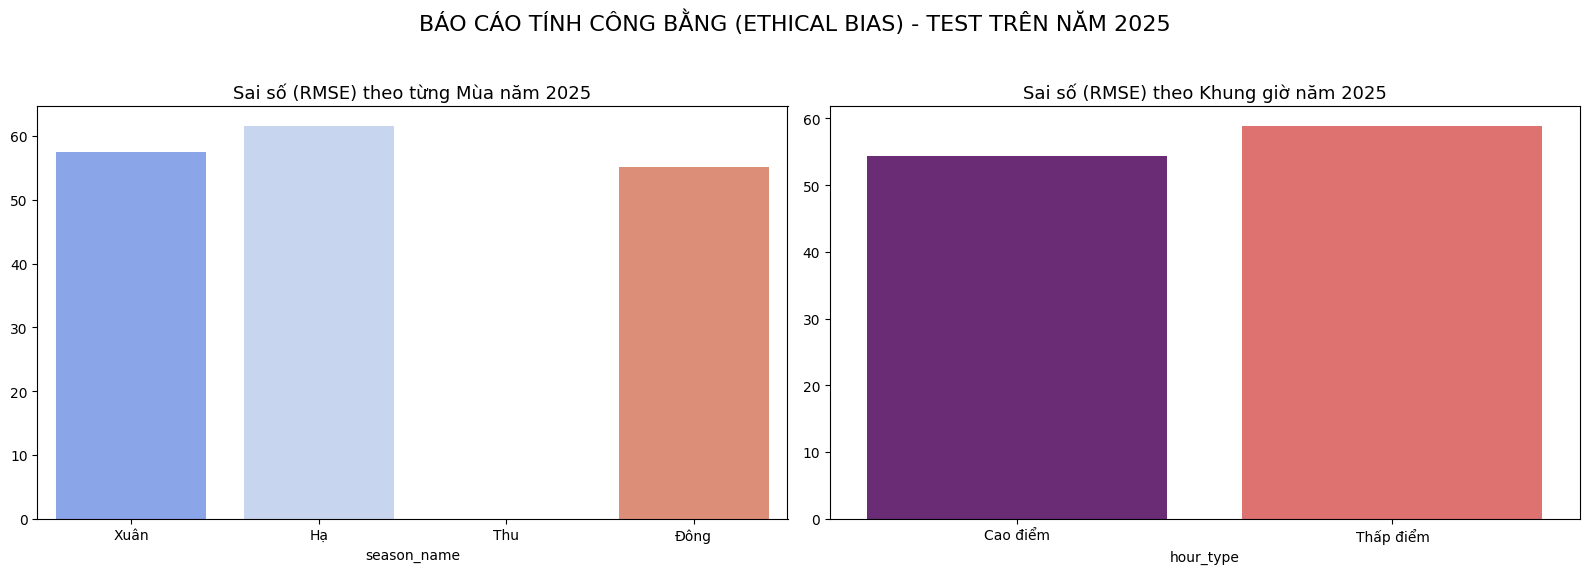


KẾT LUẬN: Sai số cao nhất rơi vào mùa HẠ.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# 1. ĐỌC DỮ LIỆU
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')
df['ds'] = pd.to_datetime(df['local_time'])
df['y'] = df['aqi']

# 2. CHIA DỮ LIỆU THEO NĂM (TRAIN: 2022-2024 | TEST: 2025)
# Chia mốc này để có trọn vẹn 1 năm đánh giá Bias 4 mùa
train = df[df['ds'] < '2025-01-01']
test = df[(df['ds'] >= '2025-01-01') & (df['ds'] <= '2025-12-31')]

print(f"Dữ liệu Train: {train['ds'].min()} đến {train['ds'].max()}")
print(f"Dữ liệu Test (để soi Bias): Năm 2025")

# 3. HUẤN LUYỆN MÔ HÌNH
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

# 4. DỰ BÁO CHO NĂM 2025
future = model.make_future_dataframe(periods=len(test), freq='H')
forecast = model.predict(future)

# --- BIỂU ĐỒ 1: DỰ BÁO TỔNG QUAN 2025 ---
plt.figure(figsize=(15, 6))
plt.plot(test['ds'], test['y'], label='Thực tế (Actual)', color='black', alpha=0.4)
plt.plot(forecast['ds'].iloc[-len(test):], forecast['yhat'].iloc[-len(test):], label='Dự báo (Forecast)', color='red')
plt.title('Dự báo AQI Hà Nội trọn năm 2025', fontsize=14)
plt.legend(); plt.show()

# --- 5. ĐÁNH GIÁ TÍNH CÔNG BẰNG (ETHICAL BIAS REPORT) ---
eval_df = test.copy()
# Lấy kết quả dự báo khớp với mốc thời gian của tập test
forecast_test = forecast.set_index('ds').loc[test['ds']]
eval_df['pred'] = forecast_test['yhat'].values

# Map tên để biểu đồ chuyên nghiệp
eval_df['season_name'] = eval_df['season'].map({0: 'Đông', 1: 'Xuân', 2: 'Hạ', 3: 'Thu'})
eval_df['hour_type'] = eval_df['is_rush_hour'].map({1: 'Cao điểm', 0: 'Thấp điểm'})

# Tính sai số RMSE cho từng nhóm
rmse_season = eval_df.groupby('season_name').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))
rmse_hour = eval_df.groupby('hour_type').apply(lambda x: np.sqrt(mean_squared_error(x['y'], x['pred'])))

# --- BIỂU ĐỒ 2: TRỰC QUAN HÓA BIAS (QUAN TRỌNG) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bias theo Mùa
sns.barplot(x=rmse_season.index, y=rmse_season.values, ax=ax1, palette='coolwarm', order=['Xuân', 'Hạ', 'Thu', 'Đông'])
ax1.set_title('Sai số (RMSE) theo từng Mùa năm 2025', fontsize=13)

# Bias theo Khung giờ
sns.barplot(x=rmse_hour.index, y=rmse_hour.values, ax=ax2, palette='magma')
ax2.set_title('Sai số (RMSE) theo Khung giờ năm 2025', fontsize=13)

plt.suptitle('BÁO CÁO TÍNH CÔNG BẰNG (ETHICAL BIAS) - TEST TRÊN NĂM 2025', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

print(f"\nKẾT LUẬN: Sai số cao nhất rơi vào mùa {rmse_season.idxmax().upper()}.")